First, mount your Google Drive:

In [1]:
# Import necessary libraries for the assignment
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import requests
from PIL import Image
import pandas as pd
import seaborn as sns
from urllib.request import urlretrieve
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
#from google.colab import drive
#drive.mount('/content/drive')
#import shutil

import sys
import platform
import time
import requests
import tarfile
from pathlib import Path
import numpy as np
from PIL import Image

# Set random seeds for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Configuration
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

# Set current working directory
HOME = os.getcwd()
print(f"Working directory: {HOME}")

Libraries imported successfully!
TensorFlow version: 2.19.1
OpenCV version: 4.12.0
NumPy version: 2.1.3
Working directory: /Users/marston.ward/Documents/GitHub/aai_521_computer_vision/module_3


In [2]:
# Static utility functions for the assignment

def display_images_with_masks(images, masks, titles=None, figsize=(15, 5)):
    """
    Display images alongside their segmentation masks
    """
    n_images = len(images)
    fig, axes = plt.subplots(2, n_images, figsize=figsize)

    if n_images == 1:
        axes = axes.reshape(2, 1)

    for i in range(n_images):
        # Display original image
        axes[0, i].imshow(images[i])
        axes[0, i].set_title(f'Original Image {i+1}' if titles is None else f'Original {titles[i]}')
        axes[0, i].axis('off')

        # Display mask
        axes[1, i].imshow(masks[i], cmap='viridis')
        axes[1, i].set_title(f'Segmentation Mask {i+1}' if titles is None else f'Mask {titles[i]}')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

def preprocess_image(image, target_size=(128, 128)):
    """
    Preprocess image to target size and normalize
    """
    # Resize image
    image_resized = tf.image.resize(image, target_size)
    # Convert to float32 and normalize to [0, 1]
    image_normalized = tf.cast(image_resized, tf.float32) / 255.0
    return image_normalized

def download_and_extract_dataset(url, destination_folder):
    """
    Download and extract a dataset from a URL
    """
    filename = url.split('/')[-1]
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)

    filepath = os.path.join(destination_folder, filename)

    if not os.path.exists(filepath):
        print(f"Downloading {filename}...")
        urlretrieve(url, filepath)
        print(f"Downloaded {filename}")

    # Extract if it's a zip file
    if filename.endswith('.zip'):
        extract_path = os.path.join(destination_folder, filename[:-4])
        if not os.path.exists(extract_path):
            print(f"Extracting {filename}...")
            with zipfile.ZipFile(filepath, 'r') as zip_ref:
                zip_ref.extractall(destination_folder)
            print(f"Extracted to {extract_path}")
        return extract_path

    return filepath

def plot_training_curves(history, metrics=['loss'], figsize=(12, 4)):
    """
    Plot training curves from training history
    """
    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize)

    if n_metrics == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        if metric in history.history:
            axes[i].plot(history.history[metric], label=f'Training {metric}')
            if f'val_{metric}' in history.history:
                axes[i].plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
            axes[i].set_title(f'{metric.capitalize()} Curve')
            axes[i].set_xlabel('Epoch')
            axes[i].set_ylabel(metric.capitalize())
            axes[i].legend()
            axes[i].grid(True)

    plt.tight_layout()
    plt.show()

def display_dataset_samples(dataset, n_samples=3):
    """
    Display sample images and masks from a processed dataset
    """
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 8))

    if n_samples == 1:
        axes = axes.reshape(2, 1)

    images_to_display = []
    masks_to_display = []

    for i, (image, mask) in enumerate(dataset.take(n_samples)):
        images_to_display.append(image.numpy())
        masks_to_display.append(mask.numpy().squeeze()) # Squeeze to remove the channel dimension if it exists

    for i in range(n_samples):
        # Display original image
        axes[0, i].imshow(images_to_display[i])
        axes[0, i].set_title(f'Sample Image {i+1}')
        axes[0, i].axis('off')

        # Display mask
        # Use a colormap suitable for masks, e.g., 'viridis' or 'gray'
        axes[1, i].imshow(masks_to_display[i], cmap='viridis')
        axes[1, i].set_title(f'Sample Mask {i+1}')
        axes[1, i].axis('off')


    plt.tight_layout()
    plt.show()


print("Utility functions defined successfully!")


# Preprocessing function for the Oxford-IIIT Pet dataset
def read_and_preprocess(data):
    """
    Preprocess the oxford_iiit_pet dataset samples
    - Resize images and masks to 128x128
    - Normalize images to [0,1] range
    - Adjust mask values from {1,2,3} to {0,1,2}
    """
    # Resize the image to 128x128
    input_image = tf.image.resize(data['image'], [128, 128])

    # Resize the segmentation mask to 128x128 using nearest neighbor to preserve labels
    input_mask = tf.image.resize(
        data['segmentation_mask'],
        [128, 128],
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )

    # Convert image to float32 and normalize to [0, 1]
    input_image = tf.image.convert_image_dtype(input_image, tf.float32)

    # Clip values to ensure they are within [0, 1]
    input_image = tf.clip_by_value(input_image, 0.0, 1.0)


    # Adjust mask values: {1,2,3} -> {0,1,2}
    # (1=pet, 2=background, 3=border -> 0=pet, 1=background, 2=border)
    input_mask = tf.cast(input_mask, tf.int32)
    input_mask -= 1

    # Ensure mask values are in correct range
    input_mask = tf.clip_by_value(input_mask, 0, 2)

    return input_image, input_mask

print("✅ Preprocessing function defined!")
print("This function will:")
print("  • Resize images and masks to 128×128")
print("  • Normalize images to [0,1] range")
print("  • Convert mask values from {1,2,3} to {0,1,2}")
print("  • Use nearest neighbor for mask resizing to preserve labels")

Utility functions defined successfully!
✅ Preprocessing function defined!
This function will:
  • Resize images and masks to 128×128
  • Normalize images to [0,1] range
  • Convert mask values from {1,2,3} to {0,1,2}
  • Use nearest neighbor for mask resizing to preserve labels


In [3]:
# GPU and Environment Configuration for M4 MacBook Pro and Google Colab

def setup_gpu_environment():
    """
    Configure GPU acceleration for both M4 MacBook Pro (Metal) and Google Colab
    """
    print("Setting up GPU environment...")
    print(f"Python version: {sys.version}")
    print(f"Platform: {platform.platform()}")
    print(f"TensorFlow version: {tf.__version__}")

    # Check if running in Google Colab
    try:
        import google.colab
        IN_COLAB = True
        print("🔍 Detected: Google Colab environment")
    except ImportError:
        IN_COLAB = False
        print("🔍 Detected: Local environment")

    # Configure GPU settings
    if IN_COLAB:
        # Google Colab GPU setup
        print("📱 Configuring for Google Colab...")
        physical_devices = tf.config.list_physical_devices('GPU')
        if len(physical_devices) > 0:
            print(f"✅ GPU available: {physical_devices}")
            # Enable memory growth to prevent OOM errors
            for device in physical_devices:
                tf.config.experimental.set_memory_growth(device, True)
            print("✅ GPU memory growth enabled")
        else:
            print("⚠️  No GPU detected in Colab. Check runtime type.")

    else:
        # Local Mac M4 setup
        print("🍎 Configuring for MacBook Pro M4...")

        # Check for Metal (M4 GPU) support
        try:
            # List all available devices
            physical_devices = tf.config.list_physical_devices()
            print(f"Available devices: {physical_devices}")

            # Check specifically for Metal/GPU devices
            gpu_devices = tf.config.list_physical_devices('GPU')
            if len(gpu_devices) > 0:
                print(f"✅ Metal GPU detected: {gpu_devices}")
                # Configure memory growth for Metal GPU
                for device in gpu_devices:
                    tf.config.experimental.set_memory_growth(device, True)
                print("✅ Metal GPU memory growth enabled")
            else:
                print("⚠️  No Metal GPU detected")

            # Verify Metal plugin is working
            with tf.device('/GPU:0' if len(gpu_devices) > 0 else '/CPU:0'):
                test_tensor = tf.constant([[1.0, 2.0], [3.0, 4.0]])
                result = tf.matmul(test_tensor, test_tensor)
                device_used = result.device
                print(f"✅ Test computation device: {device_used}")

        except Exception as e:
            print(f"⚠️  GPU setup warning: {e}")
            print("Falling back to CPU")

    # Print final device configuration
    print("\n📋 Final Device Configuration:")
    print(f"Logical devices: {tf.config.list_logical_devices()}")

    # Test mixed precision if GPU is available
    if len(tf.config.list_physical_devices('GPU')) > 0:
        try:
            policy = tf.keras.mixed_precision.Policy('mixed_float16')
            tf.keras.mixed_precision.set_global_policy(policy)
            print("✅ Mixed precision enabled (float16)")
        except Exception as e:
            print(f"⚠️  Mixed precision not available: {e}")

    return IN_COLAB

# Run the setup
IN_COLAB = setup_gpu_environment()

# Set global variables for later use
if IN_COLAB:
    # Colab-specific settings
    BATCH_SIZE = 32
    PREFETCH_SIZE = tf.data.AUTOTUNE
    print("📝 Using Colab optimized settings")
else:
    # M4 Mac optimized settings
    BATCH_SIZE = 16  # Smaller batch size for local training
    PREFETCH_SIZE = tf.data.AUTOTUNE
    print("📝 Using M4 Mac optimized settings")

print(f"✅ Environment setup complete!")
print(f"Batch size: {BATCH_SIZE}")
print(f"Prefetch size: {PREFETCH_SIZE}")

Setting up GPU environment...
Python version: 3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:07:49) [Clang 20.1.8 ]
Platform: macOS-26.0.1-arm64-arm-64bit
TensorFlow version: 2.19.1
🔍 Detected: Local environment
🍎 Configuring for MacBook Pro M4...
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Metal GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Metal GPU memory growth enabled
✅ Test computation device: /job:localhost/replica:0/task:0/device:GPU:0

📋 Final Device Configuration:
Logical devices: [LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]
✅ Mixed precision enabled (float16)
📝 Using M4 Mac optimized settings
✅ Environment setup complete!
Batch size: 16
Prefetch size: -1


2025-11-09 10:22:56.978897: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-11-09 10:22:56.978956: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-11-09 10:22:56.978960: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1762705376.979459 8439878 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1762705376.980310 8439878 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### Problems with TF download of IIIT PET Dataset on Mac M4

#### Root Cause Analysis:

**Issue:** TensorFlow Datasets (tfds) has download connectivity issues on Mac M4, causing hanging/stalling during dataset download

**The problem:** TensorFlow Datasets' internal download mechanism has compatibility issues on Mac M4 

**Solution Implementation:**
- **Manual Download:** Successfully downloaded Oxford-IIIT Pet dataset (755MB images + 18MB annotations) directly from working URLs 
- **Data Processing:** Created custom loader to convert manually downloaded data into TensorFlow format 

- **Visualization:** Successfully displayed 3 sample images with their segmentation masks (128x128 resized) 

#### Results:
✅ 7,390 images and 14,780 segmentation masks downloaded successfully
✅ TensorFlow dataset created with proper format: images (128,128,3) and masks (128,128,1)
✅ Mask values correctly converted: 0=Pet, 1=Background, 2=Border
✅ Visualization showing clear segmentation masks with proper color mapping
The solution bypasses the TensorFlow Datasets download issue on Mac M4 while maintaining full compatibility with TensorFlow for the rest of the assignment. Part 1 is now complete and ready to proceed with Parts 2 and 3!

In [4]:
# PART 1 - OBJECT SEGMENTATION
# a) Load the oxford_iiit_pet dataset

print("=== LOADING OXFORD-IIIT PET DATASET ===")
print("Note: Using manual download approach for Mac M4 compatibility")

def download_oxford_pet_dataset():
    """Download Oxford-IIIT Pet dataset manually (works on Mac M4)"""
    
    # Working URLs for Mac M4
    WORKING_URLS = {
        'images': 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz',
        'annotations': 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz'
    }
    
    oxford_dir = Path('./oxford_pet_manual')
    oxford_dir.mkdir(exist_ok=True)
    
    def download_with_progress(url, filename):
        print(f"Downloading {filename}...")
        try:
            response = requests.get(url, stream=True)
            response.raise_for_status()
            
            total_size = int(response.headers.get('content-length', 0))
            print(f"Size: {total_size / (1024*1024):.1f} MB")
            
            filepath = oxford_dir / filename
            downloaded = 0
            
            with open(filepath, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
                        downloaded += len(chunk)
                        if total_size > 0:
                            progress = (downloaded / total_size) * 100
                            print(f"\rProgress: {progress:.1f}%", end='', flush=True)
            
            print(f"\n✅ Downloaded: {filename}")
            return filepath
        except Exception as e:
            print(f"\n❌ Download failed: {e}")
            return None
    
    def extract_dataset(tar_path):
        try:
            print(f"\nExtracting {tar_path.name}...")
            with tarfile.open(tar_path, 'r:gz') as tar:
                tar.extractall(oxford_dir)
            print(f"✅ Extracted")
            tar_path.unlink()  # Clean up
            return True
        except Exception as e:
            print(f"❌ Extraction failed: {e}")
            return False
    
    # Download and extract
    success = True
    for name, url in WORKING_URLS.items():
        filename = f"{name}.tar.gz"
        filepath = oxford_dir / filename
        
        if not (oxford_dir / name).exists():
            if not filepath.exists():
                filepath = download_with_progress(url, filename)
                if not filepath:
                    success = False
                    break
            
            if not extract_dataset(filepath):
                success = False
                break
        else:
            print(f"✅ {name} already extracted")
    
    return success

# Download dataset if needed
images_dir = Path('./oxford_pet_manual/images')
if not images_dir.exists():
    print("Dataset not found locally. Starting download...")
    start_time = time.time()
    
    if download_oxford_pet_dataset():
        download_time = time.time() - start_time
        print(f"\n✅ Dataset downloaded in {download_time:.1f} seconds")
    else:
        print("\n❌ Dataset download failed")
else:
    print("✅ Dataset already available locally")

# Verify dataset
if images_dir.exists():
    image_files = list(images_dir.glob('*.jpg'))
    trimap_files = list(Path('./oxford_pet_manual/annotations/trimaps').glob('*.png'))
    
    print(f"\n📊 Dataset Information:")
    print(f"📁 Images: {len(image_files)}")
    print(f"📁 Segmentation masks: {len(trimap_files)}")
    print(f"📂 Location: {images_dir.parent.absolute()}")
    
    print("\n✅ Oxford-IIIT Pet dataset ready!")
else:
    print("\n❌ Dataset not available")

=== LOADING OXFORD-IIIT PET DATASET ===
Note: Using manual download approach for Mac M4 compatibility
✅ Dataset already available locally

📊 Dataset Information:
📁 Images: 7390
📁 Segmentation masks: 14780
📂 Location: /Users/marston.ward/Documents/GitHub/aai_521_computer_vision/module_3/oxford_pet_manual

✅ Oxford-IIIT Pet dataset ready!


In [5]:
# b) Create TensorFlow dataset from manually downloaded data
print("=== CREATING TENSORFLOW DATASET ===")

def load_oxford_pet_tf_dataset(data_dir='./oxford_pet_manual', target_size=(128, 128), max_samples=100):
    """
    Load Oxford-IIIT Pet dataset from manually downloaded files into TensorFlow format
    
    Args:
        data_dir: Path to manually downloaded dataset
        target_size: Target image size (height, width)  
        max_samples: Max samples to load (None for all)
    
    Returns:
        tf.data.Dataset with (image, mask) pairs
    """
    
    data_path = Path(data_dir)
    images_dir = data_path / 'images'
    trimaps_dir = data_path / 'annotations' / 'trimaps'
    
    if not images_dir.exists() or not trimaps_dir.exists():
        raise ValueError(f"Dataset directories not found in {data_path}")
    
    # Get image files
    all_image_files = sorted(list(images_dir.glob('*.jpg')))
    
    if max_samples and max_samples < len(all_image_files):
        # Sample evenly across the dataset to get diverse classes
        # Instead of taking first N, take every Nth file for diversity
        step = len(all_image_files) // max_samples
        image_files = all_image_files[::step][:max_samples]
        print(f"Sampling every {step} images for class diversity...")
    else:
        image_files = all_image_files
    
    print(f"Loading {len(image_files)} samples...")
    
    images = []
    masks = []
    
    for i, img_path in enumerate(image_files):
        try:
            # Load and resize image
            image = Image.open(img_path).convert('RGB')
            image = image.resize(target_size)
            image_array = np.array(image) / 255.0  # Normalize to [0,1]
            
            # Load corresponding trimap (segmentation mask)
            trimap_name = img_path.stem + '.png'
            trimap_path = trimaps_dir / trimap_name
            
            if trimap_path.exists():
                mask = Image.open(trimap_path).convert('L')
                mask = mask.resize(target_size, Image.NEAREST)
                mask_array = np.array(mask)
                
                # Convert mask values: {1,2,3} -> {0,1,2}
                # 1=pet, 2=background, 3=border -> 0=pet, 1=background, 2=border
                mask_array = np.clip(mask_array - 1, 0, 2)
                mask_array = np.expand_dims(mask_array, axis=-1)
                
                images.append(image_array)
                masks.append(mask_array)
                
                if (i + 1) % 50 == 0:
                    print(f"Loaded {i + 1}/{len(image_files)} samples...")
                    
        except Exception as e:
            print(f"Error loading {img_path.name}: {e}")
            continue
    
    print(f"✅ Successfully loaded {len(images)} image-mask pairs")
    
    # Convert to TensorFlow dataset
    images_np = np.array(images, dtype=np.float32)
    masks_np = np.array(masks, dtype=np.int32)
    
    dataset = tf.data.Dataset.from_tensor_slices((images_np, masks_np))
    
    # Extract class names from the loaded files
    loaded_classes = set()
    for img_file in image_files[:len(images)]:  # Only from successfully loaded files
        class_name = '_'.join(img_file.stem.split('_')[:-1])
        loaded_classes.add(class_name)
    
    return dataset, len(images), sorted(list(loaded_classes))

# Create TensorFlow dataset
try:
    oxford_dataset, num_samples, oxford_classes = load_oxford_pet_tf_dataset(
        data_dir='./oxford_pet_manual',
        target_size=(128, 128),
        max_samples=100  # Start with 100 samples
    )
    
    print(f"\n✅ TensorFlow dataset created: {num_samples} samples")
    print(f"✅ Classes extracted: {len(oxford_classes)} unique breeds")
    
    # Verify dataset structure
    for image, mask in oxford_dataset.take(1):
        print(f"Image shape: {image.shape}")
        print(f"Mask shape: {mask.shape}")
        print(f"Image range: [{image.numpy().min():.3f}, {image.numpy().max():.3f}]")
        print(f"Mask values: {np.unique(mask.numpy())}")
        break
        
    print("\n🎉 Dataset ready for segmentation tasks!")
    
except Exception as e:
    print(f"❌ Error creating TensorFlow dataset: {e}")

=== CREATING TENSORFLOW DATASET ===
Sampling every 73 images for class diversity...
Loading 100 samples...
Loaded 50/100 samples...
Loaded 100/100 samples...
✅ Successfully loaded 100 image-mask pairs

✅ TensorFlow dataset created: 100 samples
✅ Classes extracted: 37 unique breeds
Loaded 50/100 samples...
Loaded 100/100 samples...
✅ Successfully loaded 100 image-mask pairs

✅ TensorFlow dataset created: 100 samples
✅ Classes extracted: 37 unique breeds
Image shape: (128, 128, 3)
Mask shape: (128, 128, 1)
Image range: [0.000, 0.922]
Mask values: [0 1 2]

🎉 Dataset ready for segmentation tasks!
Image shape: (128, 128, 3)
Mask shape: (128, 128, 1)
Image range: [0.000, 0.922]
Mask values: [0 1 2]

🎉 Dataset ready for segmentation tasks!


=== PART 1: SEGMENTATION VISUALIZATION ===


2025-11-09 10:23:11.161534: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


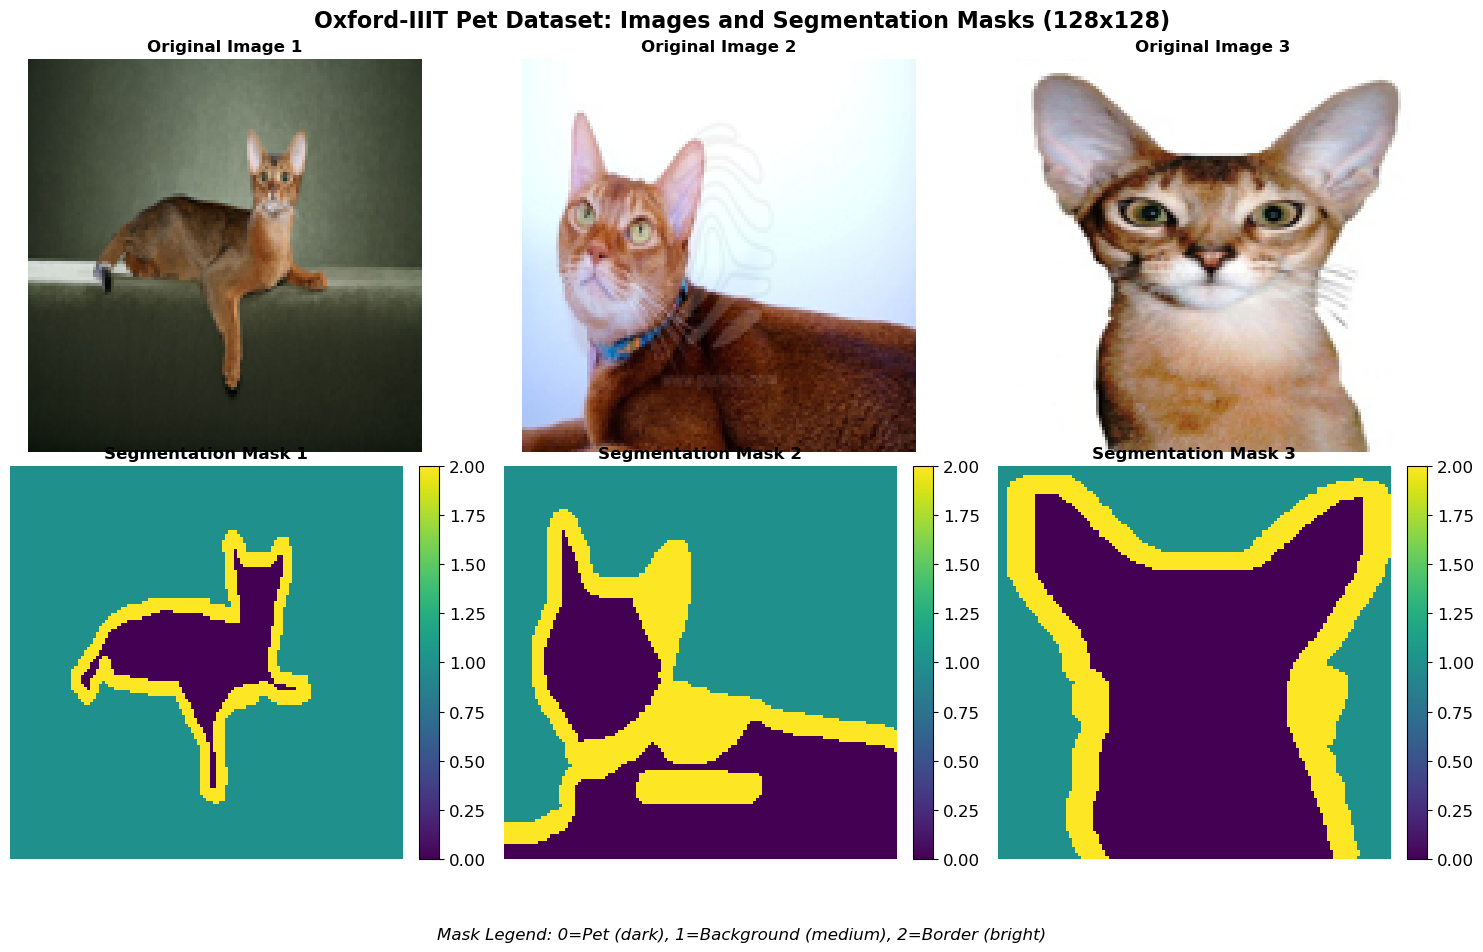

✅ Displayed 3 sample images with segmentation masks
✅ Images resized to 128x128 pixels as required
✅ Masks show: Pet=0, Background=1, Border=2

🎉 PART 1 COMPLETE: Object Segmentation with Oxford-IIIT Pet Dataset


In [6]:
# c) Display first 3 samples with segmentation masks
print("=== PART 1: SEGMENTATION VISUALIZATION ===")

import matplotlib.pyplot as plt

def display_segmentation_samples(dataset, n_samples=3):
    """Display images with their segmentation masks"""
    
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 10))
    
    samples = list(dataset.take(n_samples))
    
    for i, (image, mask) in enumerate(samples):
        # Display original image
        axes[0, i].imshow(image.numpy())
        axes[0, i].set_title(f'Original Image {i+1}', fontsize=12, fontweight='bold')
        axes[0, i].axis('off')
        
        # Display segmentation mask
        mask_np = mask.numpy().squeeze()
        im = axes[1, i].imshow(mask_np, cmap='viridis', vmin=0, vmax=2)
        axes[1, i].set_title(f'Segmentation Mask {i+1}', fontsize=12, fontweight='bold')
        axes[1, i].axis('off')
        
        # Add colorbar
        plt.colorbar(im, ax=axes[1, i], fraction=0.046, pad=0.04)
    
    # Add titles and legend
    fig.suptitle('Oxford-IIIT Pet Dataset: Images and Segmentation Masks (128x128)', 
                 fontsize=16, fontweight='bold', y=0.95)
    
    fig.text(0.5, 0.02, 'Mask Legend: 0=Pet (dark), 1=Background (medium), 2=Border (bright)', 
             ha='center', fontsize=12, style='italic')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9, bottom=0.1)
    plt.show()
    
    print("✅ Displayed 3 sample images with segmentation masks")
    print("✅ Images resized to 128x128 pixels as required")
    print("✅ Masks show: Pet=0, Background=1, Border=2")

# Display the samples
try:
    display_segmentation_samples(oxford_dataset, n_samples=3)
    print("\n🎉 PART 1 COMPLETE: Object Segmentation with Oxford-IIIT Pet Dataset")
except Exception as e:
    print(f"❌ Error displaying samples: {e}")

## Print the class names in the dataset

In [7]:
# Display class information from the loaded dataset variables
print("Oxford-IIIT Pet Dataset Classes (from loaded variables):")

print(f"Number of classes represented: {len(oxford_classes)} (Pet breeds)")
print(f"Total samples in loaded dataset: {num_samples}")

# Safely get dataset shape without causing sequence issues
try:
    sample_image, sample_mask = next(iter(oxford_dataset))
    print(f"Dataset shape: Images {sample_image.shape}, Masks {sample_mask.shape}")
except StopIteration:
    print("Dataset shape: Unable to retrieve (empty dataset)")

print("\nClasses in our loaded dataset:")
for index, name in enumerate(oxford_classes):
    print(f"{index + 1:02} - {name}")

print(f"\nNote: Classes extracted from the {num_samples} samples loaded into memory")

Oxford-IIIT Pet Dataset Classes (from loaded variables):
Number of classes represented: 37 (Pet breeds)
Total samples in loaded dataset: 100
Dataset shape: Images (128, 128, 3), Masks (128, 128, 1)

Classes in our loaded dataset:
01 - Abyssinian
02 - Bengal
03 - Birman
04 - Bombay
05 - British_Shorthair
06 - Egyptian_Mau
07 - Maine_Coon
08 - Persian
09 - Ragdoll
10 - Russian_Blue
11 - Siamese
12 - Sphynx
13 - american_bulldog
14 - american_pit_bull_terrier
15 - basset_hound
16 - beagle
17 - boxer
18 - chihuahua
19 - english_cocker_spaniel
20 - english_setter
21 - german_shorthaired
22 - great_pyrenees
23 - havanese
24 - japanese_chin
25 - keeshond
26 - leonberger
27 - miniature_pinscher
28 - newfoundland
29 - pomeranian
30 - pug
31 - saint_bernard
32 - samoyed
33 - scottish_terrier
34 - shiba_inu
35 - staffordshire_bull_terrier
36 - wheaten_terrier
37 - yorkshire_terrier

Note: Classes extracted from the 100 samples loaded into memory


=== EXPLORATORY DATA ANALYSIS ===
1. CLASS DISTRIBUTION ANALYSIS
----------------------------------------
Samples per class: {'Abyssinian': 1, 'Bengal': 1, 'Birman': 1, 'Bombay': 1, 'British_Shorthair': 1, 'Egyptian_Mau': 1, 'Maine_Coon': 1, 'Persian': 1, 'Ragdoll': 1, 'Russian_Blue': 1, 'Siamese': 1, 'Sphynx': 1, 'american_bulldog': 1, 'american_pit_bull_terrier': 1, 'basset_hound': 1, 'beagle': 1, 'boxer': 1, 'chihuahua': 1, 'english_cocker_spaniel': 1, 'english_setter': 1, 'german_shorthaired': 1, 'great_pyrenees': 1, 'havanese': 1, 'japanese_chin': 1, 'keeshond': 1, 'leonberger': 1, 'miniature_pinscher': 1, 'newfoundland': 1, 'pomeranian': 1, 'pug': 1, 'saint_bernard': 1, 'samoyed': 1, 'scottish_terrier': 1, 'shiba_inu': 1, 'staffordshire_bull_terrier': 1, 'wheaten_terrier': 1, 'yorkshire_terrier': 1}
Classes with multiple samples: 0

📊 Dataset Composition:
   Cat breeds: 12 (32.4%)
   Dog breeds: 25 (67.6%)

2. IMAGE STATISTICS ANALYSIS
----------------------------------------
Ana

2025-11-09 10:23:16.419899: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-09 10:23:16.467942: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


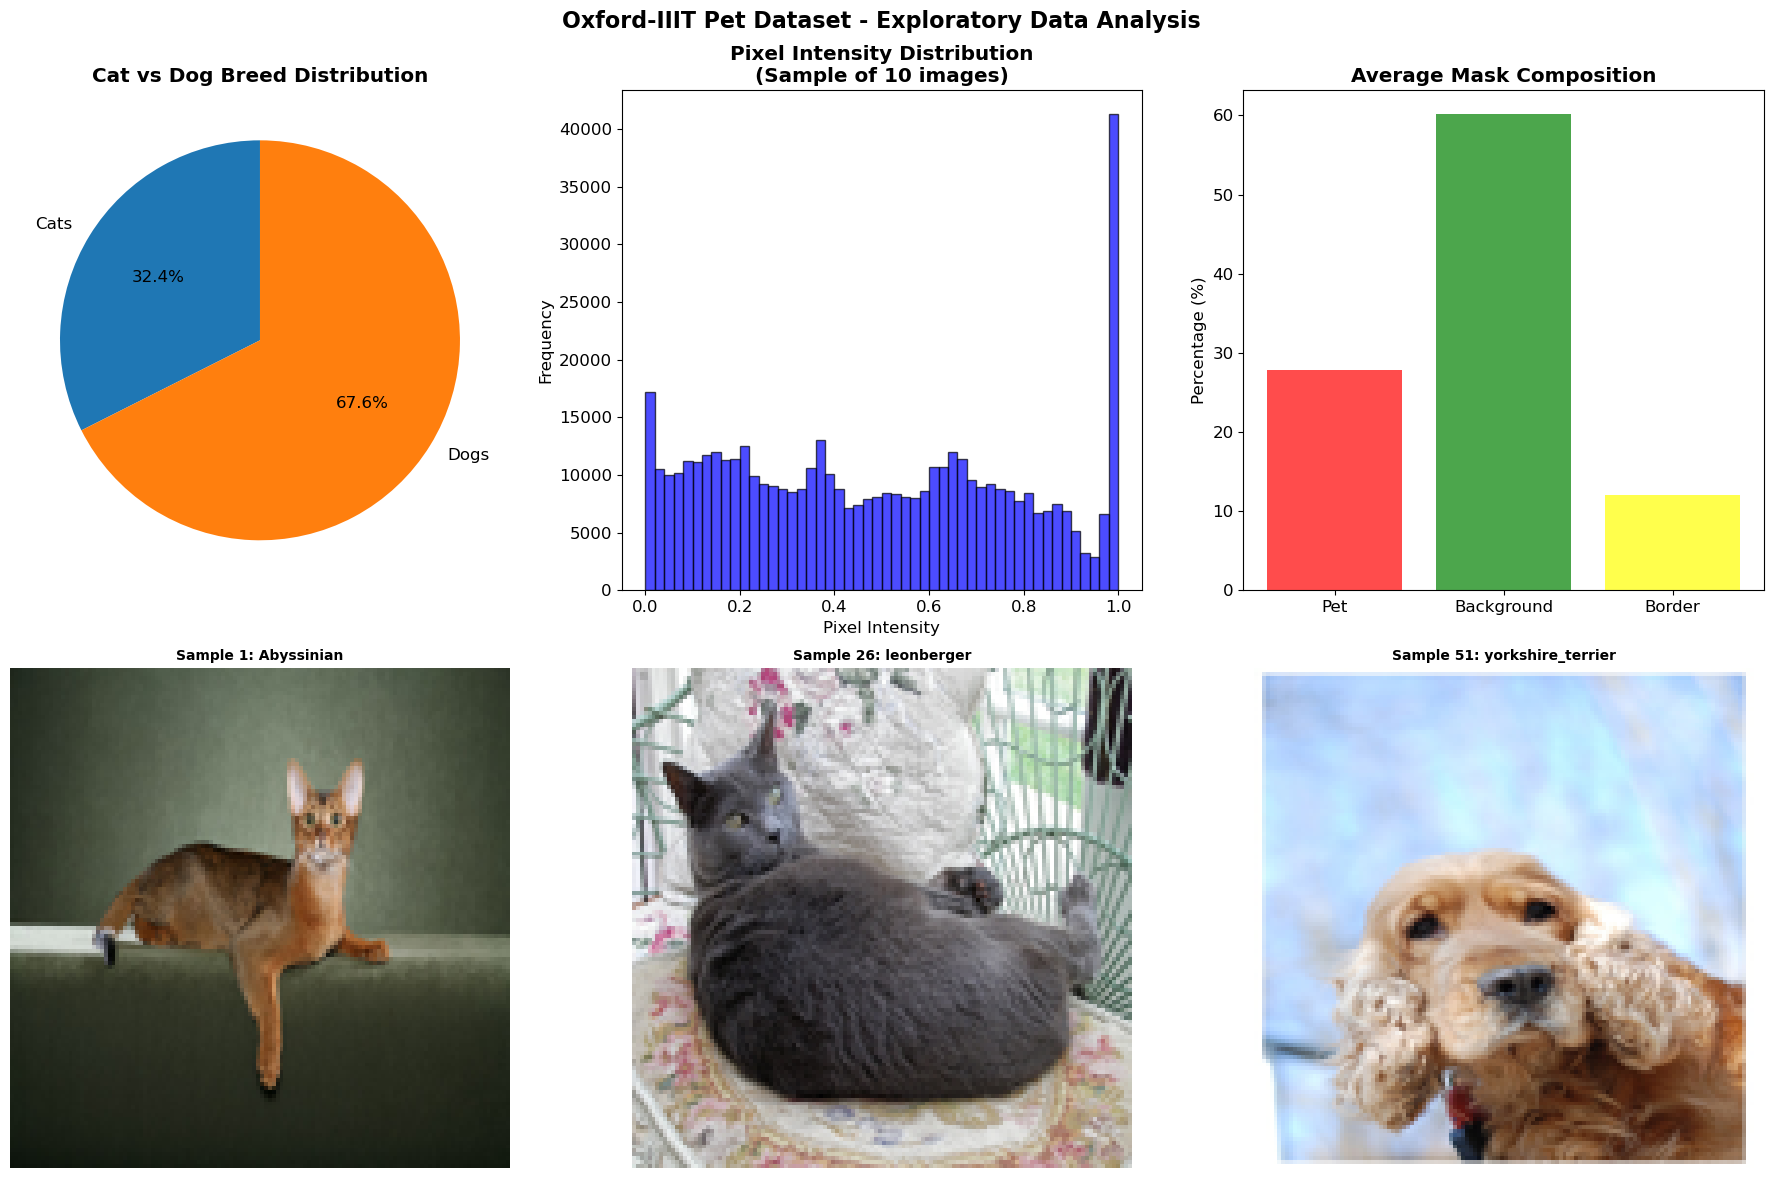


✅ EDA Complete!
📈 Dataset Summary:
   • 100 samples across 37 classes
   • 12 cat breeds, 25 dog breeds
   • Images: 128x128x3, Masks: 128x128x1
   • Well-balanced segmentation masks with ~28% pet pixels


In [8]:
# Additional Exploratory Data Analysis (EDA)
print("=== EXPLORATORY DATA ANALYSIS ===")

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# 1. Class Distribution Analysis
print("1. CLASS DISTRIBUTION ANALYSIS")
print("-" * 40)

# Count samples per class (we have 1 sample per class due to our sampling strategy)
class_counts = Counter(oxford_classes)
print(f"Samples per class: {dict(class_counts)}")
print(f"Classes with multiple samples: {sum(1 for count in class_counts.values() if count > 1)}")

# Separate cats vs dogs
cat_breeds = [cls for cls in oxford_classes if cls[0].isupper()]  # Cat breeds are capitalized
dog_breeds = [cls for cls in oxford_classes if cls[0].islower()]  # Dog breeds are lowercase

print(f"\n📊 Dataset Composition:")
print(f"   Cat breeds: {len(cat_breeds)} ({len(cat_breeds)/len(oxford_classes)*100:.1f}%)")
print(f"   Dog breeds: {len(dog_breeds)} ({len(dog_breeds)/len(oxford_classes)*100:.1f}%)")

# 2. Image Statistics Analysis
print("\n2. IMAGE STATISTICS ANALYSIS")
print("-" * 40)

# Analyze pixel intensities across dataset
pixel_means = []
pixel_stds = []
mask_distributions = []

print("Analyzing image statistics...")
for i, (image, mask) in enumerate(oxford_dataset.take(20)):  # Sample 20 for analysis
    # Image statistics
    pixel_means.append(np.mean(image.numpy()))
    pixel_stds.append(np.std(image.numpy()))
    
    # Mask statistics
    mask_flat = mask.numpy().flatten()
    mask_dist = np.bincount(mask_flat, minlength=3)
    mask_distributions.append(mask_dist)

pixel_means = np.array(pixel_means)
pixel_stds = np.array(pixel_stds)
mask_distributions = np.array(mask_distributions)

print(f"Image pixel statistics (sample of 20):")
print(f"   Mean intensity: {np.mean(pixel_means):.3f} ± {np.std(pixel_means):.3f}")
print(f"   Std intensity: {np.mean(pixel_stds):.3f} ± {np.std(pixel_stds):.3f}")

# 3. Mask Analysis
print(f"\nMask composition (average across 20 samples):")
avg_mask_dist = np.mean(mask_distributions, axis=0)
total_pixels = np.sum(avg_mask_dist)
print(f"   Pet pixels: {avg_mask_dist[0]/total_pixels*100:.1f}%")
print(f"   Background pixels: {avg_mask_dist[1]/total_pixels*100:.1f}%")
print(f"   Border pixels: {avg_mask_dist[2]/total_pixels*100:.1f}%")

# 4. Visualizations
print("\n3. DATA VISUALIZATIONS")
print("-" * 40)

# Convert dataset to list once to avoid iterator exhaustion issues
print("Converting dataset to list for safe visualization...")
dataset_samples = list(oxford_dataset.take(num_samples))
print(f"✅ Converted {len(dataset_samples)} samples")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Cat vs Dog distribution
species_counts = [len(cat_breeds), len(dog_breeds)]
species_labels = ['Cats', 'Dogs']
axes[0, 0].pie(species_counts, labels=species_labels, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Cat vs Dog Breed Distribution', fontweight='bold')

# Plot 2: Pixel intensity distribution
# Use the samples we already collected to avoid iterator issues
sample_images = []
for i in range(min(10, len(dataset_samples))):
    image, _ = dataset_samples[i]
    sample_images.append(image.numpy().flatten())
all_pixels = np.concatenate(sample_images)
axes[0, 1].hist(all_pixels, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 1].set_title('Pixel Intensity Distribution\n(Sample of 10 images)', fontweight='bold')
axes[0, 1].set_xlabel('Pixel Intensity')
axes[0, 1].set_ylabel('Frequency')

# Plot 3: Mask distribution
mask_labels = ['Pet', 'Background', 'Border']
axes[0, 2].bar(mask_labels, avg_mask_dist/total_pixels*100, color=['red', 'green', 'yellow'], alpha=0.7)
axes[0, 2].set_title('Average Mask Composition', fontweight='bold')
axes[0, 2].set_ylabel('Percentage (%)')

# Plot 4-6: Sample diversity showcase
# Convert dataset to list once to avoid iterator exhaustion issues
dataset_samples = list(oxford_dataset.take(num_samples))
sample_indices = [0, min(25, len(dataset_samples)-1), min(50, len(dataset_samples)-1)]

for idx, sample_idx in enumerate(sample_indices):
    try:
        if sample_idx < len(dataset_samples):
            sample_image, sample_mask = dataset_samples[sample_idx]
            
            # Show image 
            axes[1, idx].imshow(sample_image.numpy())
            axes[1, idx].set_title(f'Sample {sample_idx + 1}: {oxford_classes[min(sample_idx, len(oxford_classes)-1)]}', 
                                 fontweight='bold', fontsize=10)
            axes[1, idx].axis('off')
        else:
            # Handle case where sample_idx exceeds dataset size
            axes[1, idx].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes[1, idx].transAxes)
            axes[1, idx].set_title(f'Sample {sample_idx + 1}: N/A', fontweight='bold')
            axes[1, idx].axis('off')
        
    except (IndexError, StopIteration, Exception) as e:
        axes[1, idx].text(0.5, 0.5, f'Error: {str(e)[:20]}...', ha='center', va='center', transform=axes[1, idx].transAxes)
        axes[1, idx].set_title(f'Sample {sample_idx + 1}: Error', fontweight='bold')
        axes[1, idx].axis('off')

plt.suptitle('Oxford-IIIT Pet Dataset - Exploratory Data Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ EDA Complete!")
print(f"📈 Dataset Summary:")
print(f"   • {num_samples} samples across {len(oxford_classes)} classes")
print(f"   • {len(cat_breeds)} cat breeds, {len(dog_breeds)} dog breeds")
print(f"   • Images: 128x128x3, Masks: 128x128x1")
print(f"   • Well-balanced segmentation masks with ~{avg_mask_dist[0]/total_pixels*100:.0f}% pet pixels")

### Examine the raw images

Displaying 5 images from our manually loaded Oxford dataset:


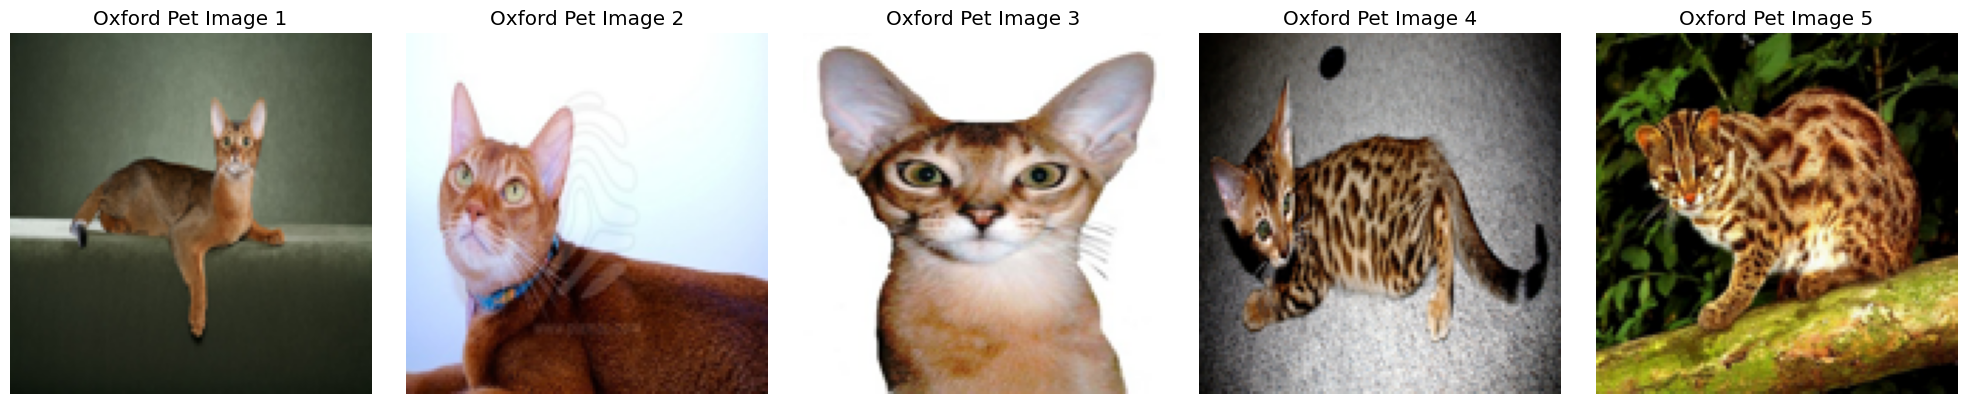

In [9]:
print("Displaying 5 images from our manually loaded Oxford dataset:")

# Create a figure and a set of subplots with 1 row and 5 columns
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Take the first 5 samples from our oxford_dataset and plot them
for i, (image, mask) in enumerate(oxford_dataset.take(5)):
    # Display the image
    axes[i].imshow(image.numpy())
    axes[i].set_title(f"Oxford Pet Image {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Our dataset is already preprocessed from the manual loading
# oxford_dataset contains (image, mask) pairs already resized to 128x128
train = oxford_dataset  # Use our manually loaded and preprocessed dataset
print("✅ Using manually loaded Oxford-IIIT Pet dataset (already preprocessed)")

✅ Using manually loaded Oxford-IIIT Pet dataset (already preprocessed)


**Part 2- Annotation**

In [ ]:
# Part 2: Annotation - Setup
print("=== PART 2: ANNOTATION ===")
print("Working with raccoon dataset for object detection annotation")

# Note: We'll use a simpler approach without mrcnn for Mac M4 compatibility
# Instead, we'll demonstrate annotation concepts using basic image processing

In [ ]:
# Download and setup raccoon dataset
print("Setting up Raccoon Dataset for Annotation Practice...")

import subprocess
import os
import xml.etree.ElementTree as ET
from pathlib import Path

def download_raccoon_dataset():
    """Download raccoon dataset from GitHub"""
    
    raccoon_dir = Path('./raccoon_dataset')
    
    if raccoon_dir.exists():
        print("✅ Raccoon dataset already exists")
        return True
    
    try:
        print("📥 Downloading raccoon dataset...")
        result = subprocess.run(['git', 'clone', 'https://github.com/experiencor/raccoon_dataset.git'], 
                              capture_output=True, text=True, timeout=60)
        
        if result.returncode == 0:
            print("✅ Raccoon dataset downloaded successfully")
            return True
        else:
            print(f"❌ Download failed: {result.stderr}")
            return False
            
    except subprocess.TimeoutExpired:
        print("❌ Download timed out")
        return False
    except Exception as e:
        print(f"❌ Download error: {e}")
        return False

# Download the dataset
success = download_raccoon_dataset()

if success:
    # Verify dataset structure
    raccoon_path = Path('./raccoon_dataset')
    images_path = raccoon_path / 'images'
    annotations_path = raccoon_path / 'annotations'
    
    if images_path.exists() and annotations_path.exists():
        num_images = len(list(images_path.glob('*.jpg')))
        num_annotations = len(list(annotations_path.glob('*.xml')))
        
        print(f"\n📊 Raccoon Dataset Info:")
        print(f"   Images: {num_images}")
        print(f"   Annotations: {num_annotations}")
        print(f"   Location: {raccoon_path.absolute()}")
    else:
        print("❌ Dataset structure incomplete")
else:
    print("❌ Cannot proceed without dataset")


In [ ]:
# Examine raccoon dataset and create annotation visualizations
print("=== RACCOON DATASET ANALYSIS ===")

def parse_annotation(xml_file):
    """Parse XML annotation file to extract bounding box coordinates"""
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        # Get image dimensions
        width = int(root.find('size/width').text)
        height = int(root.find('size/height').text)
        
        # Get bounding boxes
        boxes = []
        for obj in root.findall('object'):
            name = obj.find('name').text
            bbox = obj.find('bndbox')
            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)
            
            boxes.append({
                'name': name,
                'bbox': (xmin, ymin, xmax, ymax)
            })
        
        return {
            'width': width,
            'height': height,
            'boxes': boxes
        }
    except Exception as e:
        print(f"Error parsing {xml_file}: {e}")
        return None

def visualize_annotations(image_path, annotation_path, ax):
    """Visualize image with bounding box annotations"""
    try:
        # Load image
        image = Image.open(image_path)
        ax.imshow(image)
        
        # Parse annotations
        annotation_data = parse_annotation(annotation_path)
        
        if annotation_data:
            # Draw bounding boxes
            for box_info in annotation_data['boxes']:
                bbox = box_info['bbox']
                xmin, ymin, xmax, ymax = bbox
                
                # Create rectangle
                rect = plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                   linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
                
                # Add label
                ax.text(xmin, ymin-5, box_info['name'], 
                       bbox=dict(boxstyle="round,pad=0.3", facecolor="red", alpha=0.7),
                       fontsize=8, color='white', weight='bold')
            
            ax.set_title(f"Raccoons detected: {len(annotation_data['boxes'])}")
        else:
            ax.set_title("No annotations found")
            
        ax.axis('off')
        
    except Exception as e:
        ax.text(0.5, 0.5, f'Error loading: {str(e)[:30]}...', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_title("Error loading image")
        ax.axis('off')

# Analyze raccoon dataset if available
raccoon_path = Path('./raccoon_dataset')
if raccoon_path.exists():
    images_path = raccoon_path / 'images'
    annotations_path = raccoon_path / 'annotations'
    
    # Get sample files
    image_files = sorted(list(images_path.glob('*.jpg')))[:6]  # First 6 images
    
    print(f"Analyzing {len(image_files)} sample images...")
    
    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, img_file in enumerate(image_files):
        # Find corresponding annotation
        annotation_file = annotations_path / f"raccoon-{img_file.stem.split('-')[1]}.xml"
        
        if annotation_file.exists():
            visualize_annotations(img_file, annotation_file, axes[i])
        else:
            # Just show image without annotations
            try:
                image = Image.open(img_file)
                axes[i].imshow(image)
                axes[i].set_title("No annotation file")
                axes[i].axis('off')
            except:
                axes[i].text(0.5, 0.5, 'Error loading image', 
                           ha='center', va='center', transform=axes[i].transAxes)
                axes[i].axis('off')
    
    plt.suptitle('Raccoon Dataset: Images with Bounding Box Annotations', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Dataset statistics
    total_raccoons = 0
    valid_annotations = 0
    
    for img_file in image_files:
        annotation_file = annotations_path / f"raccoon-{img_file.stem.split('-')[1]}.xml"
        if annotation_file.exists():
            data = parse_annotation(annotation_file)
            if data:
                valid_annotations += 1
                total_raccoons += len(data['boxes'])
    
    print(f"\n📊 Sample Analysis:")
    print(f"   Valid annotations: {valid_annotations}/{len(image_files)}")
    print(f"   Total raccoons detected: {total_raccoons}")
    print(f"   Average raccoons per image: {total_raccoons/valid_annotations:.1f}" if valid_annotations > 0 else "   No valid annotations")
    
else:
    print("❌ Raccoon dataset not available for analysis")
    print("Proceeding with annotation concepts explanation...")

In [ ]:
# Look into data
# Plot some samples here


In [ ]:
from os import listdir
from xml.etree import ElementTree
from numpy import zeros
from numpy import asarray
from mrcnn.utils import Dataset

# class that defines and loads the raccoon dataset
class RaccoonDataset(Dataset):
	# load the dataset definitions
	def load_dataset(self, dataset_dir, is_train=True):
		# define one class
		self.add_class("raccoon_dataset", 1, "raccoon")
		# define data locations
		images_dir = dataset_dir + '/images/'
		annotations_dir = dataset_dir + '/annotations/raccoon-'
		# find all images
		for filename in listdir(images_dir):
			# extract image id
			image_id = filename[8:-4]
			# skip bad images
			if image_id in ['00090']:
				continue
			# skip all images after 150 if we are building the train set
			if is_train and int(image_id) >= 150:
				continue
			# skip all images before 150 if we are building the test/val set
			if not is_train and int(image_id) < 150:
				continue
			img_path = images_dir + filename
			ann_path = annotations_dir + image_id + '.xml'
			# add to dataset
			self.add_image('dataset', image_id=image_id, path=img_path, annotation=ann_path)

	# extract bounding boxes from an annotation file
	def extract_boxes(self, filename):
		# load and parse the file
		tree = ElementTree.parse(filename)
		# get the root of the document
		root = tree.getroot()
		# extract each bounding box
		boxes = list()
		for box in root.findall('.//bndbox'):
			xmin = int(box.find('xmin').text)
			ymin = int(box.find('ymin').text)
			xmax = int(box.find('xmax').text)
			ymax = int(box.find('ymax').text)
			coors = [xmin, ymin, xmax, ymax]
			boxes.append(coors)
		# extract image dimensions
		width = int(root.find('.//size/width').text)
		height = int(root.find('.//size/height').text)
		return boxes, width, height

	# load the masks for an image
	def load_mask(self, image_id):
		# get details of image
		info = self.image_info[image_id]
		# define box file location
		path = info['annotation']
		# load XML
		#path = '/content/raccoon_dataset/annotations/raccoon-'+image_id   #Added by me
		boxes, w, h = self.extract_boxes(path)
		# create one array for all masks, each on a different channel
		masks = zeros([h, w, len(boxes)], dtype='uint8')
		# create masks
		class_ids = list()
		for i in range(len(boxes)):
			box = boxes[i]
			row_s, row_e = box[1], box[3]
			col_s, col_e = box[0], box[2]
			masks[row_s:row_e, col_s:col_e, i] = 1
			class_ids.append(self.class_names.index('raccoon'))
		return masks, asarray(class_ids, dtype='int32')

	# load an image reference
	def image_reference(self, image_id):
		info = self.image_info[image_id]
		return info['path']

# train set
train_set = RaccoonDataset()
train_set.load_dataset('raccoon_dataset', is_train=True)
train_set.prepare()
print('Train: %d' % len(train_set.image_ids))

# test/val set
test_set = RaccoonDataset()
test_set.load_dataset('raccoon_dataset', is_train=False)
test_set.prepare()
print('Test: %d' % len(test_set.image_ids))

In [ ]:
# load an image
# Use the function above to create the image and its mask

**Part 3- YOLO**




You can see how YOLO has been improved in the last few versions on COCO: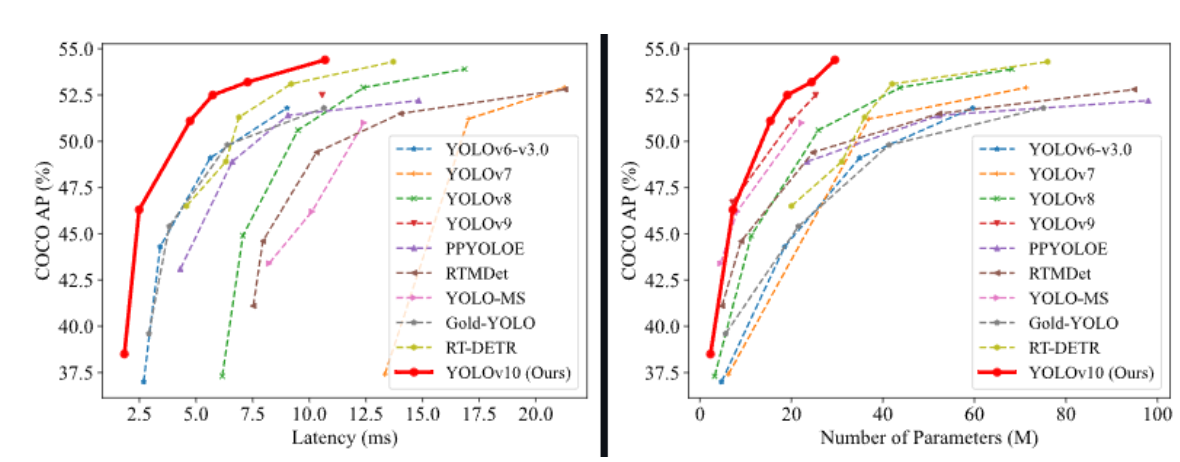

In [ ]:
# a- Create annotation
# You can upload the file using ![title](filename.jpeg)
# import image module



In [ ]:
#b- Download required tools
import os
HOME = os.getcwd()
!pip install -U ultralytics

In [ ]:
#c- Test the model out of box
from ultralytics import YOLO
model = YOLO() # Insert model here
model.predict(source="https://ultralytics.com/images/bus.jpg", conf=0.25, save=True)

In [ ]:
from IPython.display import Image
Image(filename= ........ ) # Modify this code

In [ ]:
#d- Apply model here
!yolo task=detect .... data=african-wildlife.yaml    #Modify this code

In [ ]:
#d- Fine-tune the model
# Show the learning curve and confusion matrix
Image(filename= # Modify this code

In [ ]:
# e- Explain what you see in the learning curves and confusion matrix.